<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Markowitz%2C%20Harry%20(1952).%20Portfolio%20Selection/Portfolio_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# --- Block 1: Import Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")
np.random.seed(42)  # reproducibility

In [8]:
# --- Block 2: Simulate Asset Returns ---
n_assets = 4
n_days = 252  # 1 year of trading days

# Define mean returns and covariance matrix
mean_returns = np.array([0.0005, 0.0007, 0.0006, 0.0008])
cov_matrix = np.array([
    [0.0001, 0.00002, 0.00003, 0.00001],
    [0.00002, 0.00015, 0.00002, 0.00003],
    [0.00003, 0.00002, 0.0002, 0.00004],
    [0.00001, 0.00003, 0.00004, 0.00025]
])

# Generate daily returns
returns = np.random.multivariate_normal(mean_returns, cov_matrix, n_days)
returns_df = pd.DataFrame(returns, columns=['Asset A', 'Asset B', 'Asset C', 'Asset D'])

# Show first few rows
returns_df.head()

,Asset A,Asset B,Asset C,Asset D
0,-0.015184,-0.004893,0.003441,-0.006450
1,-0.008359,-0.013391,0.012338,0.004962
2,0.005058,0.006038,-0.003898,0.010661
3,0.014876,0.020091,0.011539,-0.020111
4,0.016531,0.011537,-0.000517,0.015928


In this block, we simulate daily returns for four assets over one year (252 trading days). We define each asset’s expected daily return (mean_returns) and how the assets co-move via a covariance matrix (cov_matrix). Using these, we generate random daily returns from a multivariate normal distribution and store them in a DataFrame returns_df, where each column represents an asset and each row a trading day. returns_df.head() shows the first few simulated returns.

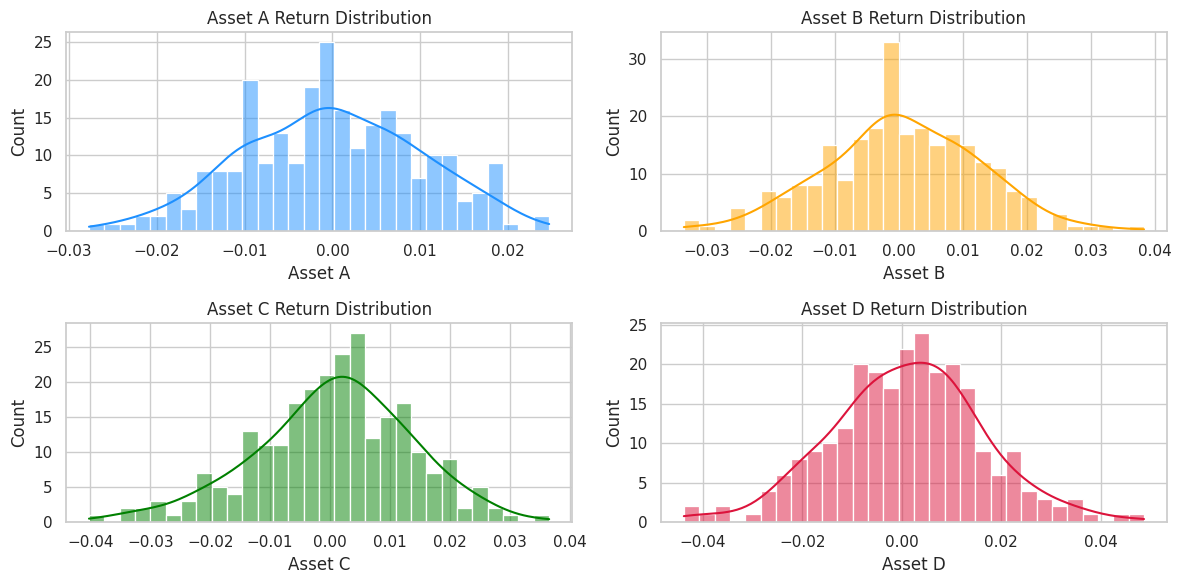

Covariance Matrix:
           Asset A   Asset B   Asset C   Asset D
Asset A  0.000103  0.000022  0.000033 -0.000002
Asset B  0.000022  0.000146  0.000010  0.000005
Asset C  0.000033  0.000010  0.000171  0.000023
Asset D -0.000002  0.000005  0.000023  0.000233

Correlation Matrix:
           Asset A   Asset B   Asset C   Asset D
Asset A  1.000000  0.176615  0.247331 -0.009929
Asset B  0.176615  1.000000  0.063378  0.027054
Asset C  0.247331  0.063378  1.000000  0.115421
Asset D -0.009929  0.027054  0.115421  1.000000


In [22]:
# --- Block 3: Statistical Properties ---
mean_daily_returns = returns_df.mean()
cov_daily_returns = returns_df.cov()
corr_daily_returns = returns_df.corr()

# Define brighter colors for each asset
colors = ['dodgerblue', 'orange', 'green', 'crimson']

# Plot histograms of asset returns
plt.figure(figsize=(12,6))
for i, col in enumerate(returns_df.columns):
    plt.subplot(2,2,i+1)
    sns.histplot(returns_df[col], bins=30, kde=True, color=colors[i])
    plt.title(f'{col} Return Distribution')
plt.tight_layout()
plt.show()

# Display covariance and correlation
print("Covariance Matrix:\n", cov_daily_returns)
print("\nCorrelation Matrix:\n", corr_daily_returns)

In this block, we compute key statistical properties of the simulated returns. We calculate the mean daily returns (mean_daily_returns), the covariance matrix (cov_daily_returns), and the correlation matrix (corr_daily_returns) to understand the assets’ individual risks and how they move together.

We then visualize each asset’s return distribution using histograms with density curves, making it easy to see their variability and shape. Finally, the covariance and correlation matrices are printed for quantitative insight into the relationships among the assets.

In [10]:
# --- Block 4: Portfolio Simulation ---
n_portfolios = 5000
results = np.zeros((3, n_portfolios))
weights_record = []

for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    port_return = np.sum(weights * mean_daily_returns) * 252
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_daily_returns*252, weights)))

    results[0,i] = port_return
    results[1,i] = port_volatility
    results[2,i] = results[0,i] / results[1,i]

weights_record = np.array(weights_record)

In this block, we simulate 5,000 random portfolios to explore the range of possible combinations of the four assets. For each portfolio, we generate random weights for the assets, normalize them so they sum to 1, and store them in weights_record. Using these weights, we calculate the expected annual return (port_return) by scaling the weighted mean daily returns and the annualized portfolio volatility (port_volatility) using the covariance matrix. Finally, we compute the Sharpe ratio (return divided by risk) for each portfolio. All results are stored in the results array, providing the data needed to analyze the efficient frontier and identify optimal portfolios.

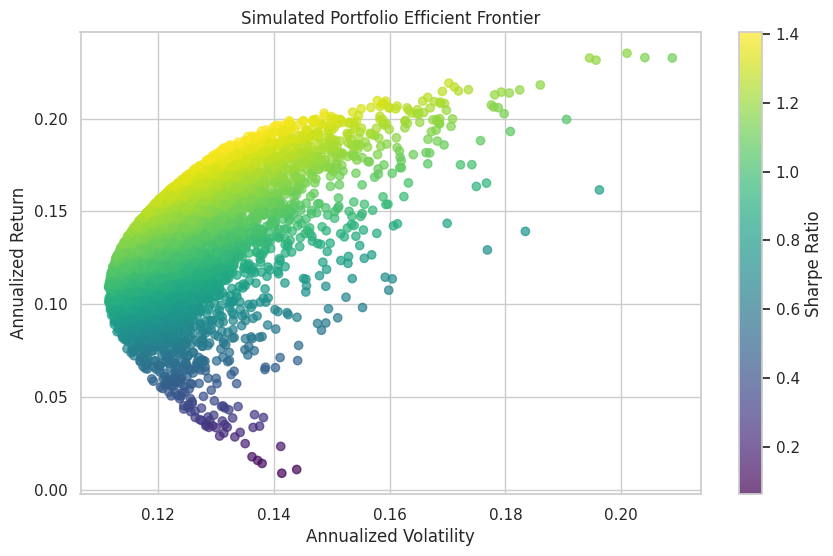

In [11]:
# --- Block 5: Efficient Frontier Plot ---
plt.figure(figsize=(10,6))
plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', marker='o', alpha=0.7)
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Simulated Portfolio Efficient Frontier')
plt.colorbar(label='Sharpe Ratio')
plt.show()

This block visualizes the efficient frontier by plotting all simulated portfolios. Each point represents a portfolio, with annualized volatility on the x-axis and annualized return on the y-axis. The points are colored by their Sharpe ratio, highlighting portfolios with the best risk-adjusted returns. This plot helps identify the trade-off between risk and return and shows which portfolios lie on the frontier of optimal performance.

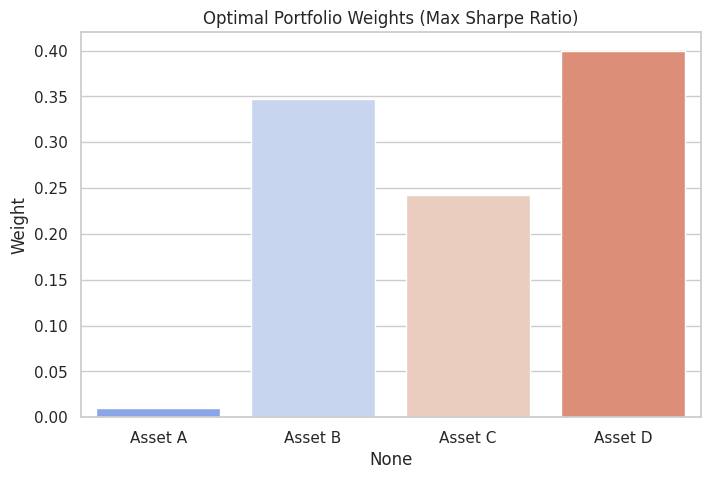

Optimal Portfolio Stats:
Asset A: 0.01
Asset B: 0.35
Asset C: 0.24
Asset D: 0.40
Expected Annual Return: 19.03%
Expected Annual Volatility: 13.55%
Sharpe Ratio: 1.40


In [20]:
# --- Block 6: Max Sharpe Ratio Portfolio ---
max_sharpe_idx = np.argmax(results[2])
optimal_weights = weights_record[max_sharpe_idx]

plt.figure(figsize=(8,5))
sns.barplot(x=returns_df.columns, y=optimal_weights, palette='coolwarm', hue=returns_df.columns, legend=False)
plt.title('Optimal Portfolio Weights (Max Sharpe Ratio)')
plt.ylabel('Weight')
plt.show()

print("Optimal Portfolio Stats:")
for i, asset in enumerate(returns_df.columns):
    print(f"{asset}: {optimal_weights[i]:.2f}")
print(f"Expected Annual Return: {results[0,max_sharpe_idx]:.2%}")
print(f"Expected Annual Volatility: {results[1,max_sharpe_idx]:.2%}")
print(f"Sharpe Ratio: {results[2,max_sharpe_idx]:.2f}")

In this block, we identify the portfolio with the **maximum Sharpe ratio**, representing the best risk-adjusted return among all simulated portfolios. The optimal asset weights are displayed in a **bar chart**, showing how much of each asset should be held. We also print the portfolio’s **expected annual return**, **annualized volatility**, and **Sharpe ratio**, providing a clear summary of its performance.


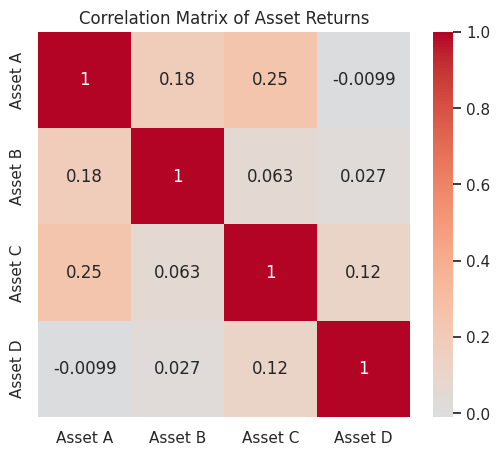

In [13]:
# --- Block 7: Correlation Heatmap ---
plt.figure(figsize=(6,5))
sns.heatmap(corr_daily_returns, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Asset Returns')
plt.show()

This block visualizes the **correlation matrix** of the simulated asset returns using a heatmap. Each cell shows the strength and direction of the relationship between two assets, with positive correlations in warm colors and negative correlations in cool colors. This provides a quick visual understanding of how the assets move together, which is crucial for assessing diversification in a portfolio.


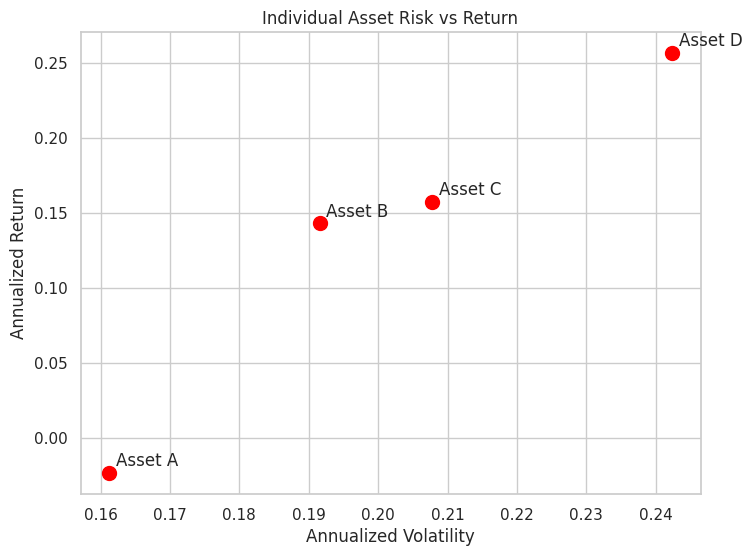

In [21]:
# --- Block 8: Volatility vs Return Scatter by Asset ---
plt.figure(figsize=(8,6))
plt.scatter(returns_df.std()*np.sqrt(252), mean_daily_returns*252, s=100, c='red')
for i, txt in enumerate(returns_df.columns):
    plt.annotate(txt, (returns_df.std().iloc[i]*np.sqrt(252), mean_daily_returns.iloc[i]*252), xytext=(5,5), textcoords='offset points')
plt.xlabel('Annualized Volatility')
plt.ylabel('Annualized Return')
plt.title('Individual Asset Risk vs Return')
plt.show()

In this block, we plot each individual asset on a **risk-return scatter plot**, with **annualized volatility** on the x-axis and **annualized return** on the y-axis. Each asset is labeled, allowing us to visually compare their risk and return characteristics. This helps highlight which assets are relatively high-return, high-risk, or low-risk, low-return, providing insight for portfolio construction and diversification decisions.
